## 01 - Graph Basics

### 3 components:
- State = a typed dict shared across the graph; only thing nodes read from/write to
- Nodes = Python functions that receive state and return a partial update
- Edges = connections between nodes; static or conditional

Everything in LangGraph is built on top of these 3 components

In [8]:
%pip install -q langgraph langchain python-dotenv

13.75s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Note: you may need to restart the kernel to use updated packages.


In [9]:
from typing import TypedDict, Annotated
import operator

from langgraph.graph import StateGraph, START, END

### Defining State
State stores a snapshot what the graph knows at a given time step. The messages field stores conversation info (user input, LLM responses; set up as a string for now). It says operator.add because we append instead of re-wrtting messages as step_count goes up.

In [11]:
class State(TypedDict):
    messages: Annotated[list[str], operator.add] 
    step_count: int

### Define Nodes

Nodes are just Python functions. They receive the full current state and return a **dict of only the fields they're updating**. LangGraph merges the return value into state using the reducers you defined above.

Key rule: **nodes never mutate state in place — they return partial updates.**

In [14]:
def node_a(state: State) -> dict:
    print(f"[node_a] step_count={state['step_count']}")
    return {
        "messages": ["node_a ran"],
        "step_count": state["step_count"] + 1
    }

def node_b(state: State) -> dict:
    print(f"[node_b] step_count={state['step_count']}")
    return {
        "messages": ["node_b ran"],
        "step_count": state["step_count"] + 1
    }


### Build the Graph

Graph construction is just wiring:
1. Add nodes
2. Add edges (`START` and `END` are built-in sentinels)
3. Compile

Compiled graphs are immutable and executable. You can also visualize them (see below).

In [15]:
builder = StateGraph(State)

# Register nodes
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)

# Wire edges: START -> node_a -> node_b -> END
builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", END)

graph = builder.compile()

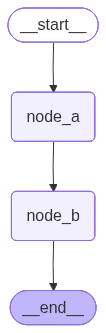

In [16]:
# Optional: visualize the graph structure (requires graphviz)
try:
    from IPython.display import Image
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())

### Run the Graph

`invoke()` runs the graph to completion and returns the final state.

The input dict is merged into state as the initial value — fields you don't include default to whatever your TypedDict implies (or raise a KeyError if you access them without setting them).

In [17]:
initial_state = {
    "messages": ["graph started"],
    "step_count": 0
}

result = graph.invoke(initial_state)

print("\n--- Final State ---")
print(f"messages : {result['messages']}")
print(f"step_count: {result['step_count']}")

[node_a] step_count=0
[node_b] step_count=1

--- Final State ---
messages : ['graph started', 'node_a ran', 'node_b ran']
step_count: 2


Notice that `messages` accumulated across all nodes because of the `operator.add` reducer. `step_count` was overwritten each time (no reducer = last-write-wins).

### 5. Conditional Edges

Static graphs aren't very interesting. The real power of LangGraph is **conditional edges** — routing logic that branches based on state.

A routing function reads state and returns the **name of the next node** as a string.

In [18]:
def route(state: State) -> str:
    """If step_count is below 3, loop back to node_a. Otherwise, finish."""
    if state["step_count"] < 3:
        return "node_a"
    return END


builder2 = StateGraph(State)

builder2.add_node("node_a", node_a)

builder2.add_edge(START, "node_a")
builder2.add_conditional_edges("node_a", route)  # route() decides what's next

graph2 = builder2.compile()

In [19]:
result2 = graph2.invoke({"messages": [], "step_count": 0})

print("\n--- Final State ---")
print(f"messages : {result2['messages']}")
print(f"step_count: {result2['step_count']}")

[node_a] step_count=0
[node_a] step_count=1
[node_a] step_count=2

--- Final State ---
messages : ['node_a ran', 'node_a ran', 'node_a ran']
step_count: 3


This is the cyclic execution pattern that makes LangGraph suitable for agent loops — a node runs, state is checked, and execution either continues or terminates.

### Summary

| Concept | What it is |
|---|---|
| `State` | Typed dict shared across all nodes; reducers control how fields merge |
| Node | Python function: `(State) -> dict` — returns partial state update |
| Static edge | Fixed connection between two nodes |
| Conditional edge | Routing function: `(State) -> str` — returns name of next node |
| `compile()` | Locks the graph; returns an executable `CompiledGraph` |
| `invoke()` | Runs graph to completion; returns final state |